In [ ]:
# Run once. ~50 MB download. Produces data/ref/gencode_v19_gene_coords.tsv
import os, urllib.request, gzip, shutil

os.makedirs("../data/ref", exist_ok=True)
url = "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_19/gencode.v19.annotation.gtf.gz"
gz = "../data/ref/gencode.v19.annotation.gtf.gz"
if not os.path.exists(gz):
    urllib.request.urlretrieve(url, gz)
    print("downloaded:", os.path.getsize(gz), "bytes")

import pandas as pd, re

rows = []
with gzip.open(gz, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        c = line.rstrip("\n").split("\t")
        if c[2] != "gene":
            continue
        chrom, start, end, attr = c[0], int(c[3]), int(c[4]), c[8]
        name = re.search(r'gene_name "([^"]+)"', attr)
        gtype = re.search(r'gene_type "([^"]+)"', attr)
        rows.append((name.group(1), chrom, start, end,
                     gtype.group(1) if gtype else "NA"))

g = pd.DataFrame(rows, columns=["symbol", "chrom", "start", "end", "gene_type"])

# Keep autosomes only (CNV inference excludes sex chromosomes — see Fig S5A: Chr 1–22)
autosomes = [f"chr{i}" for i in range(1, 23)]
g = g[g["chrom"].isin(autosomes)].copy()

# One row per symbol: if a symbol maps to multiple loci, keep the longest (most canonical)
g["length"] = g["end"] - g["start"]
g = g.sort_values("length", ascending=False).drop_duplicates("symbol", keep="first")

# Order by chromosome (1..22), then start
g["chrom_num"] = g["chrom"].str.replace("chr", "").astype(int)
g = g.sort_values(["chrom_num", "start"]).reset_index(drop=True)

g[["symbol", "chrom", "chrom_num", "start", "end"]].to_csv(
    "../data/ref/gencode_v19_gene_coords.tsv", sep="\t", index=False)

print("total autosomal genes:", len(g))
print(g.head())

downloaded: 37991892 bytes
total autosomal genes: 52947
       symbol chrom  start    end   gene_type  length  chrom_num
0     DDX11L1  chr1  11869  14412  pseudogene    2543          1
1      WASH7P  chr1  14363  29806  pseudogene   15443          1
2  MIR1302-11  chr1  29554  31109     lincRNA    1555          1
3     FAM138A  chr1  34554  36081     lincRNA    1527          1
4      OR4G4P  chr1  52473  54936  pseudogene    2463          1


In [4]:
import scanpy as sc
import numpy as np

adata = sc.read_h5ad("../data/processed/Filbin_step5.h5ad")

print("shape:", adata.shape)  # expect (2454, 8494)

# Step 4 anchors carry forward
assert "X_tsne_centered" in adata.obsm, "missing t-SNE"
assert "centered" in adata.layers and "tpm" in adata.layers, "missing layers"
assert {"correlation_centered", "distance_centered"}.issubset(adata.obsp), "missing obsp"

# Step 5 score columns
score_cols = [c for c in adata.obs.columns if c.startswith("score_")]
print("score cols:", sorted(score_cols))  # expect 8

# Step 5 NM payload
nm = adata.uns["step5_nm"]
print("uns step5_nm keys:", list(nm.keys()))

# Per-patient counts (anchor)
print(adata.obs["patient"].value_counts())  # MUV5 706, BCH836 527, BCH869 492, BCH1126 299, MUV10 284, MUV1 146

shape: (2454, 8494)
score cols: ['score_AC', 'score_Cellcycle', 'score_NM_immune', 'score_NM_oligodendrocyte', 'score_OC', 'score_OPC_shared', 'score_OPC_variable', 'score_P4_OPC_merged']
uns step5_nm keys: ['finding', 'group_summary', 'immune_high_cells', 'nm_threshold', 'oligo_high_cells', 'reference_oligo_cells', 'reference_scores']
MUV5       706
BCH836     527
BCH869     492
BCH1126    299
MUV10      284
MUV1       146
Name: patient, dtype: int64


In [5]:
import pandas as pd
import numpy as np

# Load the parsed coords
coords = pd.read_csv("../data/ref/gencode_v19_gene_coords.tsv", sep="\t")
coords = coords.set_index("symbol")

# Join the 8,494 working genes onto coordinates
genes = pd.Index(adata.var_names)
mapped_mask = genes.isin(coords.index)

n_total = len(genes)
n_mapped = int(mapped_mask.sum())
n_unmapped = n_total - n_mapped

print(f"working genes:       {n_total}")
print(f"mapped to v19:       {n_mapped}  ({100*n_mapped/n_total:.1f}%)")
print(f"unmapped (autosome): {n_unmapped}  ({100*n_unmapped/n_total:.1f}%)")

# What are the unmapped ones? (sex-chrom genes, deprecated symbols, novel)
unmapped = genes[~mapped_mask].tolist()
print("\nfirst 40 unmapped symbols:")
print(unmapped[:40])

# Build the ordered CNV gene table (mapped genes only), ordered by chrom then start
gmap = coords.loc[genes[mapped_mask], ["chrom", "chrom_num", "start", "end"]].copy()
gmap["working_idx"] = [adata.var_names.get_loc(s) for s in gmap.index]
gmap = gmap.sort_values(["chrom_num", "start"])

print(f"\nordered CNV gene table: {len(gmap)} genes")

# Genes per chromosome — the moving average of 100 needs enough genes per chrom
per_chrom = gmap.groupby("chrom_num").size()
print("\ngenes per chromosome:")
for chrom_num, n in per_chrom.items():
    flag = "  <-- fewer than window (100)" if n < 100 else ""
    print(f"  chr{chrom_num:>2}: {n:>4}{flag}")

print(f"\nmin per chrom: {per_chrom.min()} (chr{per_chrom.idxmin()})")
print(f"max per chrom: {per_chrom.max()} (chr{per_chrom.idxmax()})")

working genes:       8494
mapped to v19:       7986  (94.0%)
unmapped (autosome): 508  (6.0%)

first 40 unmapped symbols:
['ABCB7', 'ACOT9', 'ACSL4', 'AGPAT4-IT1', 'AGXT2L1', 'AGXT2L2', 'AIFM1', 'ALG13', 'AP1S2', 'APEX2', 'APOO', 'APOOL', 'ARAF', 'ARHGEF6', 'ARHGEF9', 'ARMCX1', 'ARMCX2', 'ARMCX3', 'ARMCX4', 'ARMCX5', 'ARMCX6', 'ARRDC3-AS1', 'ASMTL', 'ATP6AP1', 'ATP6AP2', 'ATPBD4', 'ATRX', 'BCAP31', 'BEX1', 'BEX2', 'BEX4', 'BEX5', 'BGN', 'BHLHB9', 'BRCC3', 'C16orf88', 'C1GALT1C1', 'C1orf114', 'C20orf111', 'C22orf28']

ordered CNV gene table: 7986 genes

genes per chromosome:
  chr 1:  926
  chr 2:  616
  chr 3:  520
  chr 4:  315
  chr 5:  404
  chr 6:  395
  chr 7:  409
  chr 8:  286
  chr 9:  321
  chr10:  325
  chr11:  435
  chr12:  441
  chr13:  153
  chr14:  258
  chr15:  266
  chr16:  336
  chr17:  477
  chr18:  110
  chr19:  508
  chr20:  222
  chr21:   84  <-- fewer than window (100)
  chr22:  179

min per chrom: 84 (chr21)
max per chrom: 926 (chr1)


In [6]:
import numpy as np
import pandas as pd

# ---- Build the ordered expression submatrix on centered layer ----
# gmap is already ordered by (chrom_num, start) from the previous substep.
# Pull the centered expression for the mapped genes, in genomic order.
order_idx = gmap["working_idx"].to_numpy()
E = adata.layers["centered"][:, order_idx]
E = np.asarray(E.todense()) if hasattr(E, "todense") else np.asarray(E)  # (cells, 7986)

chrom_of_gene = gmap["chrom_num"].to_numpy()  # length 7986, genomic order
n_cells, n_genes = E.shape
print("ordered expression matrix:", E.shape)

# ---- Centered moving average within each chromosome, window=min(100,n) ----
WINDOW = 100

def chrom_moving_average(mat, half):
    """Centered moving average along genes (axis=1) for ONE chromosome block.
    Window shrinks at edges; never wraps. half = window//2."""
    c = mat.shape[1]
    out = np.empty_like(mat, dtype=np.float64)
    # cumulative sum trick with per-column variable window
    csum = np.concatenate([np.zeros((mat.shape[0], 1)), np.cumsum(mat, axis=1)], axis=1)
    for j in range(c):
        lo = max(0, j - half)
        hi = min(c, j + half + 1)          # exclusive
        out[:, j] = (csum[:, hi] - csum[:, lo]) / (hi - lo)
    return out

cnv = np.empty_like(E, dtype=np.float64)
window_used = {}
for cn in np.unique(chrom_of_gene):
    cols = np.where(chrom_of_gene == cn)[0]
    block = E[:, cols]
    w = min(WINDOW, block.shape[1])
    window_used[int(cn)] = w
    half = w // 2
    cnv[:, cols] = chrom_moving_average(block, half)

print("window used per chrom:", window_used)  # chr21 -> 84, rest -> 100

# ---- Store CNV matrix + ordering provenance ----
adata.uns["step6_cnv_order"] = {
    "symbols": gmap.index.to_numpy().astype(str),
    "chrom_num": chrom_of_gene.astype(int),
    "start": gmap["start"].to_numpy().astype(int),
    "window_used": window_used,
    "n_genes": int(n_genes),
    "build": "GENCODE_v19_GRCh37",
}
adata.obsm["X_cnv_raw"] = cnv  # (cells, 7986), pre-reference-subtraction

# ---- Quick sanity anchors ----
print("\nCNV matrix:", cnv.shape)
print("global mean (should be ~0, inherited from centered):", f"{cnv.mean():.5f}")
print("per-cell CNV std range:",
      f"{cnv.std(axis=1).min():.4f} – {cnv.std(axis=1).max():.4f}")

ordered expression matrix: (2454, 7986)
window used per chrom: {1: 100, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 100, 10: 100, 11: 100, 12: 100, 13: 100, 14: 100, 15: 100, 16: 100, 17: 100, 18: 100, 19: 100, 20: 100, 21: 84, 22: 100}

CNV matrix: (2454, 7986)
global mean (should be ~0, inherited from centered): -0.00021
per-cell CNV std range: 0.1183 – 0.5170


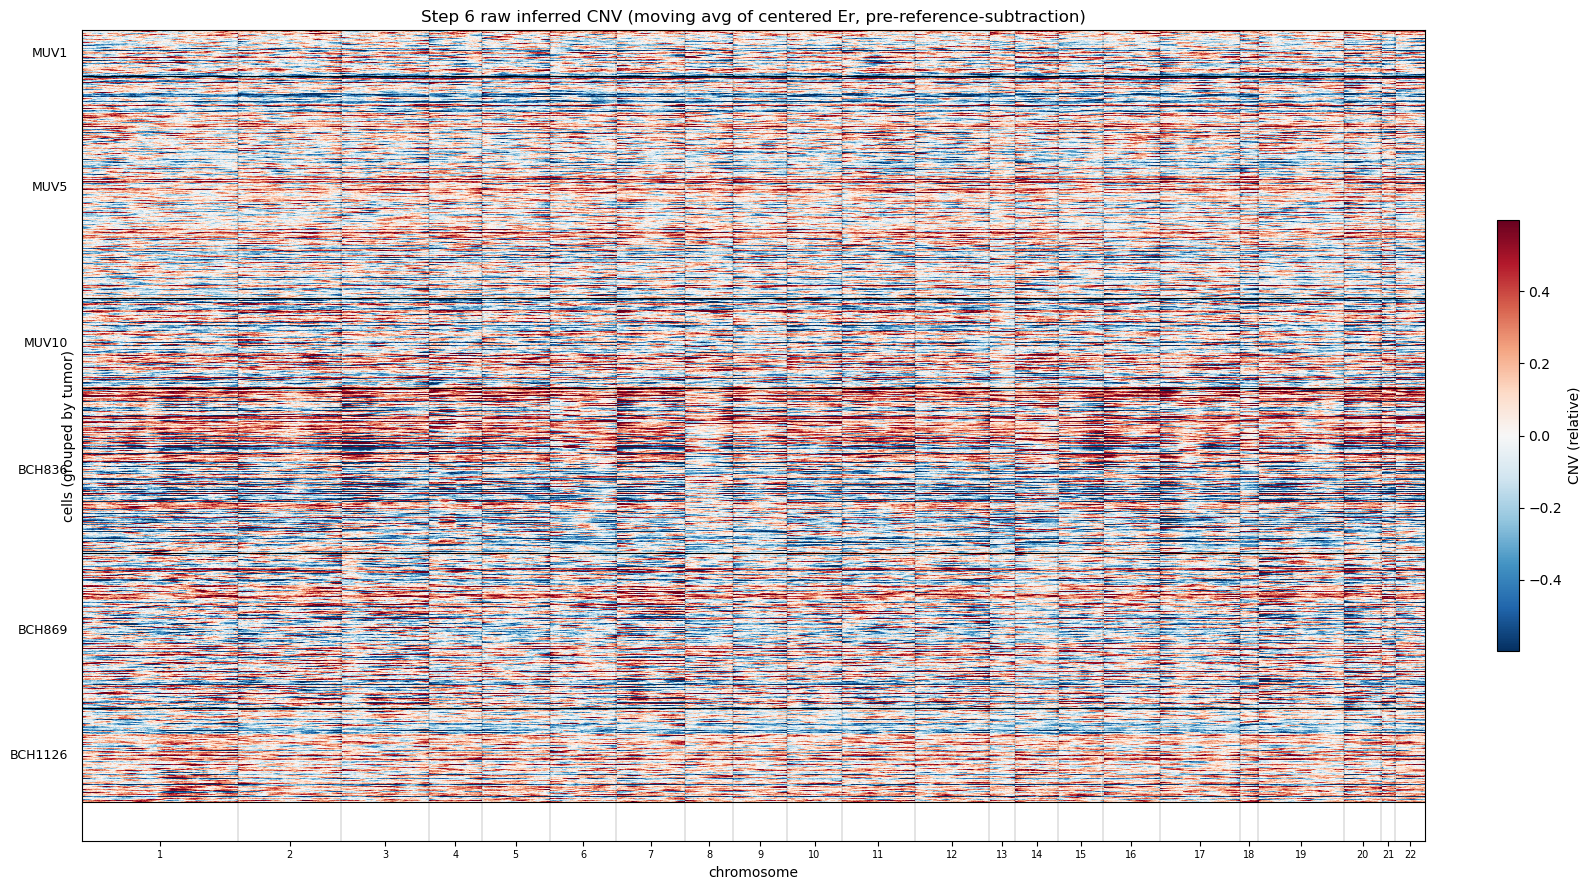

In [7]:
import matplotlib.pyplot as plt
import os
os.makedirs("../figures/step6", exist_ok=True)

# Order cells by tumor (group rows), genes already in genomic order
tumor_order = ["MUV1", "MUV5", "MUV10", "BCH836", "BCH869", "BCH1126"]
cell_order, tumor_bounds, pos = [], [], 0
for t in tumor_order:
    idx = np.where(adata.obs["patient"].to_numpy() == t)[0]
    cell_order.extend(idx.tolist())
    pos += len(idx)
    tumor_bounds.append((t, pos))
cell_order = np.array(cell_order)

# Chromosome boundaries (for vertical lines)
chrom_bounds = np.where(np.diff(chrom_of_gene) != 0)[0] + 1

fig, ax = plt.subplots(figsize=(16, 9))
vlim = np.percentile(np.abs(cnv), 95)
im = ax.imshow(cnv[cell_order], aspect="auto", cmap="RdBu_r",
               vmin=-vlim, vmax=vlim, interpolation="none")
for b in chrom_bounds:
    ax.axvline(b, color="k", lw=0.3, alpha=0.5)
prev = 0
for t, b in tumor_bounds:
    ax.axhline(b, color="k", lw=0.8)
    ax.text(-len(chrom_of_gene)*0.01, (prev+b)/2, t, ha="right", va="center", fontsize=9)
    prev = b
# chromosome labels at midpoints
mids, prevc = [], 0
for b in list(chrom_bounds) + [n_genes]:
    mids.append((prevc + b)/2); prevc = b
ax.set_xticks(mids)
ax.set_xticks(mids); ax.set_xticklabels([f"{i}" for i in range(1,23)], fontsize=7)
ax.set_yticks([]); ax.set_xlabel("chromosome"); ax.set_ylabel("cells (grouped by tumor)")
ax.set_title("Step 6 raw inferred CNV (moving avg of centered Er, pre-reference-subtraction)")
plt.colorbar(im, ax=ax, fraction=0.015, label="CNV (relative)")
plt.tight_layout()
plt.savefig("../figures/step6/step6_cnv_raw_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
import pandas as pd

ref_ids = adata.uns["step5_nm"]["reference_oligo_cells"]
ref_ids = [str(x) for x in (ref_ids.tolist() if hasattr(ref_ids, "tolist") else ref_ids)]
print("n reference oligos:", len(ref_ids))

ref_mask = adata.obs_names.isin(ref_ids)
print("matched in adata:", int(ref_mask.sum()))

# Distribution of NM reference oligos across tumors
ref_by_tumor = adata.obs.loc[ref_mask, "patient"].value_counts()
print("\nNM reference oligos per tumor:")
print(ref_by_tumor)

# Cross-check: which tumors have ZERO reference cells?
all_tumors = ["MUV1","MUV5","MUV10","BCH836","BCH869","BCH1126"]
for t in all_tumors:
    n = int(ref_by_tumor.get(t, 0))
    flag = "  <-- no in-tumor reference" if n == 0 else ""
    print(f"  {t:>8}: {n}{flag}")

n reference oligos: 138
matched in adata: 0

NM reference oligos per tumor:
BCH836     0
BCH869     0
BCH1126    0
MUV1       0
MUV5       0
MUV10      0
Name: patient, dtype: int64
      MUV1: 0  <-- no in-tumor reference
      MUV5: 0  <-- no in-tumor reference
     MUV10: 0  <-- no in-tumor reference
    BCH836: 0  <-- no in-tumor reference
    BCH869: 0  <-- no in-tumor reference
   BCH1126: 0  <-- no in-tumor reference


In [9]:
import numpy as np

ref_ids = adata.uns["step5_nm"]["reference_oligo_cells"]
ref_ids = list(ref_ids.tolist() if hasattr(ref_ids, "tolist") else ref_ids)

print("=== reference_oligo_cells (from uns) ===")
print("type of container:", type(adata.uns['step5_nm']['reference_oligo_cells']))
print("n:", len(ref_ids))
print("dtype of elements:", type(ref_ids[0]))
print("first 5 raw:", ref_ids[:5])

print("\n=== adata.obs_names ===")
print("dtype:", adata.obs_names.dtype)
print("first 5:", adata.obs_names[:5].tolist())

# Are they integer positions rather than names?
print("\n=== hypothesis checks ===")
# H1: ref_ids are integer indices into obs
try:
    as_int = [int(x) for x in ref_ids[:5]]
    print("H1 ref_ids look int-castable:", as_int,
          "| max:", max(int(x) for x in ref_ids), "| n_obs:", adata.n_obs)
except Exception as e:
    print("H1 not int-castable:", e)

# H2: ref_ids match obs_names after str strip / different formatting
sample_ref = str(ref_ids[0])
print("H2 sample ref repr:", repr(sample_ref))
print("    any obs_name contains it as substring:",
      any(sample_ref in str(n) for n in adata.obs_names[:200]))

# H3: do they live in a column of obs instead?
for col in adata.obs.columns:
    vals = adata.obs[col].astype(str).values
    hits = np.isin([str(r) for r in ref_ids], vals).sum()
    if hits > 0:
        print(f"H3 column '{col}': {hits}/{len(ref_ids)} ref_ids found here")

=== reference_oligo_cells (from uns) ===
type of container: <class 'numpy.ndarray'>
n: 138
dtype of elements: <class 'str'>
first 5 raw: ['Oligo-P02-A01', 'Oligo-P02-A02', 'Oligo-P02-A03', 'Oligo-P02-A04', 'Oligo-P02-A05']

=== adata.obs_names ===
dtype: object
first 5: ['MUV1-P04-B12', 'MUV1-P04-C08', 'MUV1-P04-D09', 'MUV1-P04-D10', 'MUV1-P04-E03']

=== hypothesis checks ===
H1 not int-castable: invalid literal for int() with base 10: 'Oligo-P02-A01'
H2 sample ref repr: 'Oligo-P02-A01'
    any obs_name contains it as substring: False


In [10]:
import scanpy as sc
import numpy as np

# Where are the Oligo cells? Most likely the Step 2 or Step 3 freeze (pre in_paper_cohort filter).
# Try the earliest freeze that still has them. Adjust paths to your repo.
candidates = [
    "../data/processed/Filbin_step3.h5ad",
    "../data/processed/Filbin_cohort_raw.h5ad",
]

for path in candidates:
    try:
        a = sc.read_h5ad(path)
    except Exception as e:
        print(f"{path}: could not load ({e})")
        continue
    oligo_mask = a.obs_names.str.startswith("Oligo-")
    n_oligo = int(oligo_mask.sum())
    print(f"\n=== {path} ===")
    print("shape:", a.shape)
    print("n Oligo cells:", n_oligo)
    if n_oligo > 0:
        print("layers present:", list(a.layers.keys()))
        print("first 3 oligo names:", a.obs_names[oligo_mask][:3].tolist())
        # Does it have the centered layer? On what gene set?
        print("n_vars:", a.n_vars)
        # Check overlap of genes with the working matrix's CNV-ordered genes
        cnv_symbols = adata.uns["step6_cnv_order"]["symbols"]
        overlap = np.isin(cnv_symbols, a.var_names.to_numpy()).sum()
        print(f"CNV-ordered genes present here: {overlap}/{len(cnv_symbols)}")


=== ../data/processed/Filbin_step3.h5ad ===
shape: (2458, 8494)
n Oligo cells: 0

=== ../data/processed/Filbin_cohort_raw.h5ad ===
shape: (4058, 23686)
n Oligo cells: 138
layers present: ['tpm']
first 3 oligo names: ['Oligo-P02-A01', 'Oligo-P02-A02', 'Oligo-P02-A03']
n_vars: 23686
CNV-ordered genes present here: 7986/7986


In [11]:
import scanpy as sc
import numpy as np

# ---- Load the 138 oligos from the raw freeze (only place they exist) ----
raw = sc.read_h5ad("../data/processed/Filbin_cohort_raw.h5ad")  # 4058 x 23686, layer 'tpm'
oligo_mask = raw.obs_names.str.startswith("Oligo-")
oligo = raw[oligo_mask].copy()
print("oligo cells loaded:", oligo.n_obs)  # expect 138

# ---- Apply the SAME transform: E = log2(TPM/10 + 1) ----
# (matches Step 3; raw freeze stored TPM in layer 'tpm', and X may also be tpm — use 'tpm' explicitly)
tpm = oligo.layers["tpm"]
tpm = np.asarray(tpm.todense()) if hasattr(tpm, "todense") else np.asarray(tpm)
E_oligo_full = np.log2(tpm / 10.0 + 1.0)  # (138, 23686)

# ---- Subset to the 7,986 CNV-ordered genes, IN THE SAME GENOMIC ORDER ----
cnv_symbols = adata.uns["step6_cnv_order"]["symbols"]            # ordered, len 7986
raw_var = raw.var_names
col_for_symbol = {s: i for i, s in enumerate(raw_var)}
assert all(s in col_for_symbol for s in cnv_symbols), "a CNV symbol is missing from raw freeze"
ordered_cols = np.array([col_for_symbol[s] for s in cnv_symbols])
E_oligo = E_oligo_full[:, ordered_cols]                          # (138, 7986), genomic order
print("oligo ordered expression:", E_oligo.shape)

# ---- Option A: center oligos WITHIN their own group (per-gene mean across the 138) ----
Er_oligo = E_oligo - E_oligo.mean(axis=0, keepdims=True)         # (138, 7986)
print("oligo centered mean (should be ~0):", f"{Er_oligo.mean():.2e}")

# ---- Same moving average (reuse the identical functions/params) ----
chrom_of_gene = adata.uns["step6_cnv_order"]["chrom_num"]        # len 7986
WINDOW = 100

def chrom_moving_average(mat, half):
    c = mat.shape[1]
    out = np.empty_like(mat, dtype=np.float64)
    csum = np.concatenate([np.zeros((mat.shape[0], 1)), np.cumsum(mat, axis=1)], axis=1)
    for j in range(c):
        lo = max(0, j - half); hi = min(c, j + half + 1)
        out[:, j] = (csum[:, hi] - csum[:, lo]) / (hi - lo)
    return out

cnv_oligo = np.empty_like(Er_oligo, dtype=np.float64)
for cn in np.unique(chrom_of_gene):
    cols = np.where(chrom_of_gene == cn)[0]
    w = min(WINDOW, len(cols)); half = w // 2
    cnv_oligo[:, cols] = chrom_moving_average(Er_oligo[:, cols], half)

# ---- The reference profile = mean smoothed CNV across the 138 oligos ----
ref_profile = cnv_oligo.mean(axis=0)                             # (7986,)

# ---- VALIDATION: reference must be flat (this is the negative-control check) ----
print("\n=== reference profile diagnostics ===")
print("ref_profile mean:", f"{ref_profile.mean():.5f}")
print("ref_profile std :", f"{ref_profile.std():.5f}")
print("ref_profile abs max:", f"{np.abs(ref_profile).max():.5f}")
# Per-cell signal strength of the oligos THEMSELVES (sum of squares), pre-subtraction
oligo_signal_pre = (cnv_oligo ** 2).sum(axis=1)
print("oligo per-cell signal (pre-sub) range:",
      f"{oligo_signal_pre.min():.4f} – {oligo_signal_pre.max():.4f}")

oligo cells loaded: 138
oligo ordered expression: (138, 7986)
oligo centered mean (should be ~0): 1.32e-18

=== reference profile diagnostics ===
ref_profile mean: -0.00000
ref_profile std : 0.00000
ref_profile abs max: 0.00000
oligo per-cell signal (pre-sub) range: 159.4018 – 5373.9744


In [12]:
import numpy as np

# Tumor CNV (built earlier from layers['centered'])
cnv_tumor = adata.obsm["X_cnv_raw"]          # (2454, 7986)
tumor_signal = (cnv_tumor ** 2).sum(axis=1)

print("=== TUMOR cnv (from layers['centered']) ===")
print("value range:", f"{cnv_tumor.min():.4f} .. {cnv_tumor.max():.4f}")
print("abs mean:", f"{np.abs(cnv_tumor).mean():.4f}")
print("signal (sumsq) range:", f"{tumor_signal.min():.4f} .. {tumor_signal.max():.4f}")

print("\n=== OLIGO cnv (from raw TPM -> log2 -> within-group center) ===")
print("value range:", f"{cnv_oligo.min():.4f} .. {cnv_oligo.max():.4f}")
print("abs mean:", f"{np.abs(cnv_oligo).mean():.4f}")
print("signal (sumsq) range:", f"{oligo_signal_pre.min():.4f} .. {oligo_signal_pre.max():.4f}")

# The key question: is layers['centered'] on the SAME definition as our oligo centering?
# Compare a tumor cell's RAW centered values vs what we'd get rebuilding from tpm.
print("\n=== scale check on layers['centered'] ===")
cen = adata.layers["centered"]
cen = np.asarray(cen.todense()) if hasattr(cen, "todense") else np.asarray(cen)
print("layers['centered'] value range:", f"{cen.min():.4f} .. {cen.max():.4f}")
print("layers['centered'] abs mean:", f"{np.abs(cen).mean():.4f}")

# And what does E (uncentered) look like in the working matrix?
X = np.asarray(adata.X.todense()) if hasattr(adata.X, "todense") else np.asarray(adata.X)
print("\nadata.X value range:", f"{X.min():.4f} .. {X.max():.4f}")
print("adata.X abs mean:", f"{np.abs(X).mean():.4f}")

=== TUMOR cnv (from layers['centered']) ===
value range: -1.6288 .. 1.7445
abs mean: 0.2413
signal (sumsq) range: 123.4408 .. 6827.6518

=== OLIGO cnv (from raw TPM -> log2 -> within-group center) ===
value range: -1.1574 .. 1.5011
abs mean: 0.2214
signal (sumsq) range: 159.4018 .. 5373.9744

=== scale check on layers['centered'] ===
layers['centered'] value range: -9.3218 .. 15.0997
layers['centered'] abs mean: 1.2805

adata.X value range: 0.0000 .. 15.1504
adata.X abs mean: 1.4281


tumor signal range: 0.0155 .. 0.8550
oligo signal range: 0.0200 .. 0.6729

cells below BOTH cutoffs (NM by CNV): 166 / 2454
oligo controls below signal cutoff: 32/138
oligo controls below corr cutoff: 124/138


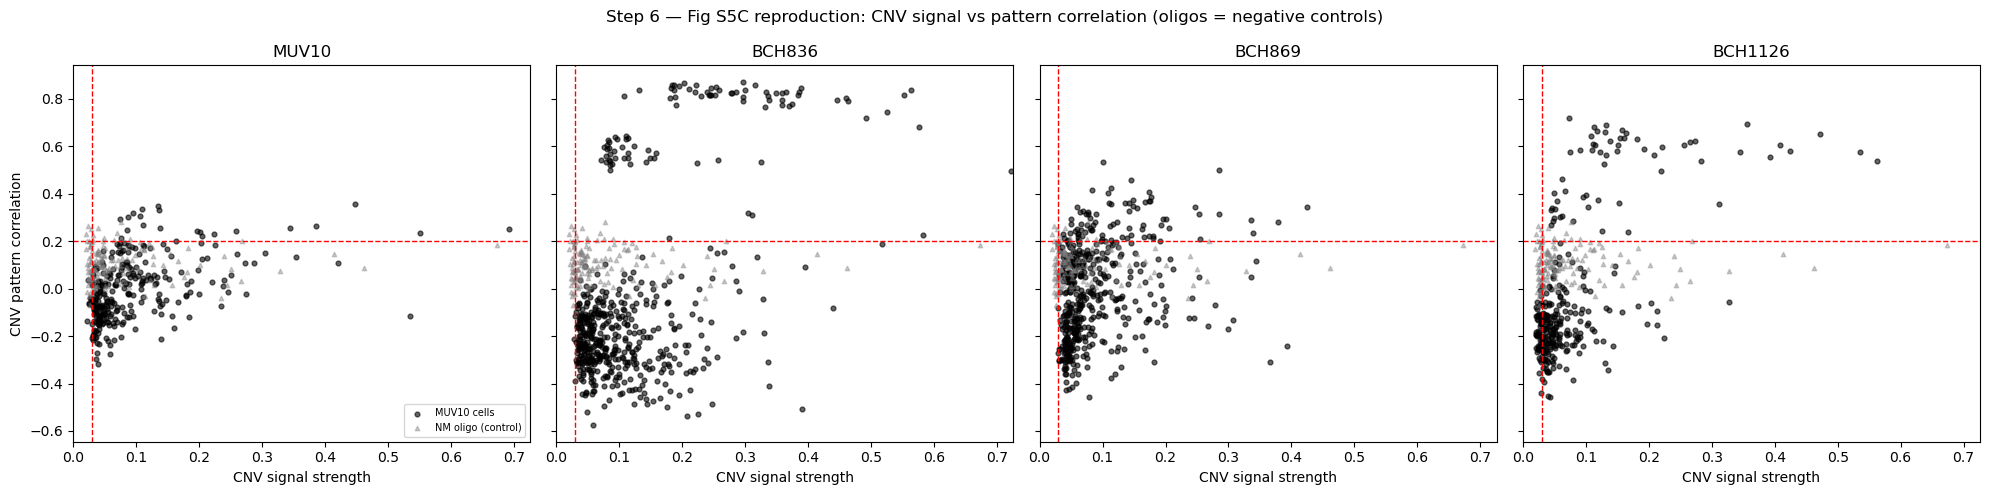

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs("../figures/step6", exist_ok=True)

cnv_tumor = adata.obsm["X_cnv_raw"]          # (2454, 7986), per-tumor-centered Er -> moving avg
patient = adata.obs["patient"].to_numpy()
tumors_with_cnv = ["MUV10", "BCH836", "BCH869", "BCH1126"]   # 4 CNV-positive (Fig S5C)
tumors_flat     = ["MUV1", "MUV5"]                            # CNV-negative

# ---- SIGNAL STRENGTH: mean-square per gene (gene-count-invariant) ----
def signal_strength(M):
    return np.mean(M**2, axis=1)

sig_tumor = signal_strength(cnv_tumor)               # (2454,)
sig_oligo = signal_strength(cnv_oligo)               # (138,)  negative controls
print("tumor signal range:", f"{sig_tumor.min():.4f} .. {sig_tumor.max():.4f}")
print("oligo signal range:", f"{sig_oligo.min():.4f} .. {sig_oligo.max():.4f}")

# ---- PATTERN CORRELATION: corr of each cell vs its tumor's mean MALIGNANT profile ----
# Bootstrap "presumed malignant" per tumor = cells above median signal in that tumor
# (Filbin used expression-cluster malignant cells; we don't have his cluster labels,
#  so we use a within-tumor high-signal seed and refine. Logged as D-Step6-malseed.)
pattern_corr = np.full(adata.n_obs, np.nan)
tumor_mean_profiles = {}
for t in np.unique(patient):
    idx = np.where(patient == t)[0]
    if t in tumors_flat:
        # no coherent malignant profile expected; correlation vs own-tumor mean still computed
        seed = idx
    else:
        s = sig_tumor[idx]
        seed = idx[s >= np.median(s)]          # high-signal seed = presumed malignant
    mean_prof = cnv_tumor[seed].mean(axis=0)
    tumor_mean_profiles[t] = mean_prof
    for i in idx:
        pattern_corr[i] = np.corrcoef(cnv_tumor[i], mean_prof)[0, 1]

# Oligo correlation: vs each tumor's malignant profile -> take MAX (most generous test)
# A true negative control should correlate poorly with ALL malignant profiles.
oligo_corr_max = np.zeros(cnv_oligo.shape[0])
for k in range(cnv_oligo.shape[0]):
    cs = [np.corrcoef(cnv_oligo[k], tumor_mean_profiles[t])[0,1] for t in tumors_with_cnv]
    oligo_corr_max[k] = np.nanmax(cs)

adata.obs["cnv_signal"] = sig_tumor
adata.obs["cnv_corr"]   = pattern_corr

# ---- Apply Filbin cutoffs: NM = signal < 0.03 AND corr < 0.2 ----
SIG_CUT, CORR_CUT = 0.03, 0.2
is_nm = (adata.obs["cnv_signal"] < SIG_CUT) & (adata.obs["cnv_corr"] < CORR_CUT)
adata.obs["cnv_nonmalignant"] = is_nm.values
print(f"\ncells below BOTH cutoffs (NM by CNV): {int(is_nm.sum())} / {adata.n_obs}")
print("oligo controls below signal cutoff:",
      f"{int((sig_oligo < SIG_CUT).sum())}/138")
print("oligo controls below corr cutoff:",
      f"{int((oligo_corr_max < CORR_CUT).sum())}/138")

# ---- Fig S5C: four scatters, one per CNV-positive tumor, oligos overlaid ----
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
for ax, t in zip(axes, tumors_with_cnv):
    idx = np.where(patient == t)[0]
    ax.scatter(sig_tumor[idx], pattern_corr[idx], s=12, c="black",
               alpha=0.6, label=f"{t} cells")
    ax.scatter(sig_oligo, oligo_corr_max, s=10, c="tab:gray",
               alpha=0.4, marker="^", label="NM oligo (control)")
    ax.axvline(SIG_CUT, color="red", ls="--", lw=1)
    ax.axhline(CORR_CUT, color="red", ls="--", lw=1)
    ax.set_title(t); ax.set_xlabel("CNV signal strength")
    ax.set_xlim(left=0)
axes[0].set_ylabel("CNV pattern correlation")
axes[0].legend(fontsize=7, loc="lower right")
plt.suptitle("Step 6 — Fig S5C reproduction: CNV signal vs pattern correlation (oligos = negative controls)")
plt.tight_layout()
plt.savefig("../figures/step6/step6_figS5C_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
import numpy as np

# Is signal dominated by an expression-variance floor shared across cells?
# Compare the smoothed profile of a clearly-normal-like tumor cell vs an oligo.
# If both have similar non-zero structure, that structure is the floor to subtract.

# Mean smoothed profile across ALL tumor cells (the "average expression landscape")
tumor_mean_all = cnv_tumor.mean(axis=0)             # (7986,)
oligo_mean_all = cnv_oligo.mean(axis=0)             # (7986,) -- NOTE: ~0 by construction (within-group center)

print("tumor mean profile abs-mean:", f"{np.abs(tumor_mean_all).mean():.4f}")
print("oligo mean profile abs-mean:", f"{np.abs(oligo_mean_all).mean():.4f}  (expected ~0)")

# Correlation of a low-signal tumor cell's profile with the tumor mean profile:
# if high, there's a shared landscape (the floor).
low_sig_idx = np.where(sig_tumor < 0.04)[0][:50]
corrs = [np.corrcoef(cnv_tumor[i], tumor_mean_all)[0,1] for i in low_sig_idx]
print("low-signal cells' corr with tumor-mean landscape:",
      f"median {np.median(corrs):.3f}")

# How much does signal drop if we subtract the all-cell tumor-mean landscape?
cnv_test = cnv_tumor - tumor_mean_all[None, :]
sig_test = np.mean(cnv_test**2, axis=1)
print("\nsignal BEFORE landscape subtraction: median",
      f"{np.median(sig_tumor):.4f}")
print("signal AFTER  landscape subtraction: median",
      f"{np.median(sig_test):.4f}")
print("oligo signal after same subtraction:",
      f"{np.median(np.mean((cnv_oligo - tumor_mean_all[None,:])**2, axis=1)):.4f}")

tumor mean profile abs-mean: 0.0002
oligo mean profile abs-mean: 0.0000  (expected ~0)
low-signal cells' corr with tumor-mean landscape: median 0.030

signal BEFORE landscape subtraction: median 0.0624
signal AFTER  landscape subtraction: median 0.0624
oligo signal after same subtraction: 0.0476


In [15]:
import numpy as np

# Distribution comparison: oligo (negative control) signal vs tumor signal
print("=== signal strength distributions ===")
for name, s in [("oligo (NM control)", sig_oligo), ("all tumor", sig_tumor)]:
    qs = np.percentile(s, [5,25,50,75,95])
    print(f"{name:>20}: p5={qs[0]:.3f} p25={qs[1]:.3f} p50={qs[2]:.3f} p75={qs[3]:.3f} p95={qs[4]:.3f}")

# Per-tumor, signal of the LOW-correlation cells (presumed NM-like) vs HIGH-corr (malignant)
print("\n=== within-tumor: signal split by correlation ===")
for t in ["MUV10","BCH836","BCH869","BCH1126"]:
    idx = np.where(adata.obs['patient'].to_numpy()==t)[0]
    c = adata.obs['cnv_corr'].to_numpy()[idx]
    s = adata.obs['cnv_signal'].to_numpy()[idx]
    hi = s[c >= 0.2]; lo = s[c < 0.2]
    print(f"{t:>8}: high-corr(malignant) median sig={np.median(hi):.3f} (n={len(hi)})  |  "
          f"low-corr median sig={np.median(lo):.3f} (n={len(lo)})")

# Where would a control-calibrated cutoff fall? (e.g. 95th pct of oligo signal)
oligo_p95 = np.percentile(sig_oligo, 95)
print(f"\noligo signal 95th percentile (candidate empirical cutoff): {oligo_p95:.4f}")
print(f"tumor cells below that cutoff: {int((sig_tumor < oligo_p95).sum())}/{len(sig_tumor)}")

=== signal strength distributions ===
  oligo (NM control): p5=0.024 p25=0.031 p50=0.048 p75=0.089 p95=0.245
           all tumor: p5=0.028 p25=0.042 p50=0.062 p75=0.113 p95=0.254

=== within-tumor: signal split by correlation ===
   MUV10: high-corr(malignant) median sig=0.139 (n=21)  |  low-corr median sig=0.062 (n=263)
  BCH836: high-corr(malignant) median sig=0.222 (n=95)  |  low-corr median sig=0.076 (n=432)
  BCH869: high-corr(malignant) median sig=0.113 (n=81)  |  low-corr median sig=0.059 (n=411)
 BCH1126: high-corr(malignant) median sig=0.130 (n=59)  |  low-corr median sig=0.044 (n=240)

oligo signal 95th percentile (candidate empirical cutoff): 0.2448
tumor cells below that cutoff: 2318/2454


In [16]:
import numpy as np

# ---- Rebuild CNV with lineage Er-cap (Tirosh 2016: clip relative expression to ±3 before smoothing) ----
# Applied to BOTH tumor cells and oligo reference, identically. Logged: D-Step6-ercap (inherited from ref 4/5).
ER_CAP = 3.0

cen = adata.layers["centered"]
cen = np.asarray(cen.todense()) if hasattr(cen, "todense") else np.asarray(cen)
order_idx = adata.uns["step6_cnv_order"]  # rebuild ordering vars
# reconstruct ordered columns from stored symbols
sym = list(order_idx["symbols"])
sym2col = {s:i for i,s in enumerate(adata.var_names)}
ordered_cols = np.array([sym2col[s] for s in sym])
chrom_of_gene = np.asarray(order_idx["chrom_num"])

E_tumor = cen[:, ordered_cols]                      # ordered, uncapped
E_tumor_capped = np.clip(E_tumor, -ER_CAP, ER_CAP)  # <-- the inherited step
print("tumor Er: values capped:", int((np.abs(E_tumor) > ER_CAP).sum()),
      f"of {E_tumor.size} ({100*(np.abs(E_tumor)>ER_CAP).mean():.3f}%)")

# oligo: rebuild capped too (E_oligo already ordered+within-group-centered from earlier)
E_oligo_capped = np.clip(Er_oligo, -ER_CAP, ER_CAP)
print("oligo Er: values capped:", int((np.abs(Er_oligo) > ER_CAP).sum()),
      f"({100*(np.abs(Er_oligo)>ER_CAP).mean():.3f}%)")

WINDOW = 100
def chrom_moving_average(mat, half):
    c = mat.shape[1]; out = np.empty_like(mat, dtype=np.float64)
    csum = np.concatenate([np.zeros((mat.shape[0],1)), np.cumsum(mat,axis=1)], axis=1)
    for j in range(c):
        lo=max(0,j-half); hi=min(c,j+half+1)
        out[:,j]=(csum[:,hi]-csum[:,lo])/(hi-lo)
    return out

def build_cnv(E):
    out = np.empty_like(E, dtype=np.float64)
    for cn in np.unique(chrom_of_gene):
        cols = np.where(chrom_of_gene==cn)[0]
        w=min(WINDOW,len(cols)); out[:,cols]=chrom_moving_average(E[:,cols], w//2)
    return out

cnv_tumor_c = build_cnv(E_tumor_capped)
cnv_oligo_c = build_cnv(E_oligo_capped)

# ---- Filbin's ACTUAL signal metric: sum of squares (not mean) ----
sig_tumor_c = (cnv_tumor_c**2).sum(axis=1)
sig_oligo_c = (cnv_oligo_c**2).sum(axis=1)

print("\n=== after Er-cap, SUM-of-squares signal ===")
print("tumor signal range:", f"{sig_tumor_c.min():.4f} .. {sig_tumor_c.max():.4f}")
print("oligo signal range:", f"{sig_oligo_c.min():.4f} .. {sig_oligo_c.max():.4f}")
print("tumor signal pctiles [5,50,95]:",
      [f"{x:.4f}" for x in np.percentile(sig_tumor_c,[5,50,95])])
print("oligo signal pctiles [5,50,95]:",
      [f"{x:.4f}" for x in np.percentile(sig_oligo_c,[5,50,95])])

tumor Er: values capped: 1561407 of 19597644 (7.967%)
oligo Er: values capped: 75428 (6.844%)

=== after Er-cap, SUM-of-squares signal ===
tumor signal range: 121.9438 .. 7048.6870
oligo signal range: 146.9606 .. 4547.8385
tumor signal pctiles [5,50,95]: ['194.3278', '464.3208', '2146.6121']
oligo signal pctiles [5,50,95]: ['163.9844', '334.4498', '2044.9072']
